In [23]:
!pip install shap
import shap
import pandas as pd
import numpy as np
import os
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.feature_selection import RFE

This cell downloads the 'home-equity-line-of-creditheloc' dataset from Kagglehub, locates the CSV file within the downloaded path, and loads it into a pandas DataFrame. This sets up the primary dataset for our analysis.

In [24]:
# Download latest version
path = kagglehub.dataset_download("averkiyoliabev/home-equity-line-of-creditheloc")

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

Using Colab cache for faster access to the 'home-equity-line-of-creditheloc' dataset.


Here, we preprocess the target variable. The 'RiskPerformance' column, indicating 'Bad' or 'Good' loans, is mapped to a numerical 'target' column (1 for 'Bad', 0 for 'Good'). The original 'RiskPerformance' column is then dropped. Finally, it prints the shape of the dataset and displays the first few rows to confirm the changes.

In [25]:
df['target'] = df['RiskPerformance'].map({'Bad': 1, 'Good': 0})
df.drop(columns=['RiskPerformance'], inplace=True)

print(f"Dataset loaded: {df.shape}")
df.head()

Dataset loaded: (10459, 24)


,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,MaxDelq2PublicRecLast12M,...,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance,target
0,55,144,4,84,20,3,0,83,2,3,...,0,0,0,33,-8,8,1,1,69,1
1,61,58,15,41,2,4,4,100,-7,0,...,0,0,0,0,-8,0,-8,-8,0,1
2,67,66,5,24,9,0,0,100,-7,7,...,0,4,4,53,66,4,2,1,86,1
3,66,169,1,73,28,1,1,93,76,6,...,0,5,4,72,83,6,4,3,91,1
4,81,333,27,132,12,0,0,100,-7,7,...,0,1,1,51,89,3,1,0,80,1


This cell visualizes the distribution of the target variable ('Good' vs. 'Bad' loans) using a count plot. This helps to understand the class balance in the dataset.

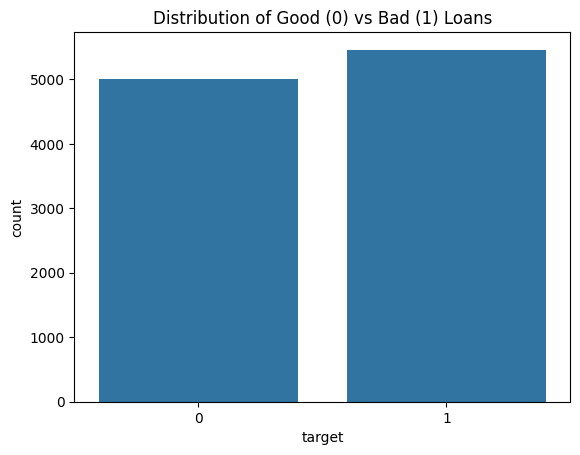

In [26]:
sns.countplot(x='target', data=df)
plt.title('Distribution of Good (0) vs Bad (1) Loans')
plt.show()

This section prepares the data for model training by separating features (X) from the target (y). It then splits the data into training and testing sets. A Random Forest Classifier is initialized and trained on the training data. Finally, it makes predictions on the test set and evaluates the model's performance using a classification report and AUC-ROC score.

In [27]:
# Define Features and Target
X = df.drop(columns=['target'])
y = df['target']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.70      0.65      0.68      1004
           1       0.70      0.75      0.72      1088

    accuracy                           0.70      2092
   macro avg       0.70      0.70      0.70      2092
weighted avg       0.70      0.70      0.70      2092

AUC-ROC Score: 0.7664


This cell calculates and visualizes the feature importance from the trained Random Forest model. It extracts the `feature_importances_` attribute, creates a DataFrame, sorts it, and then displays a bar plot of the top 10 most important features, which are considered key risk drivers.

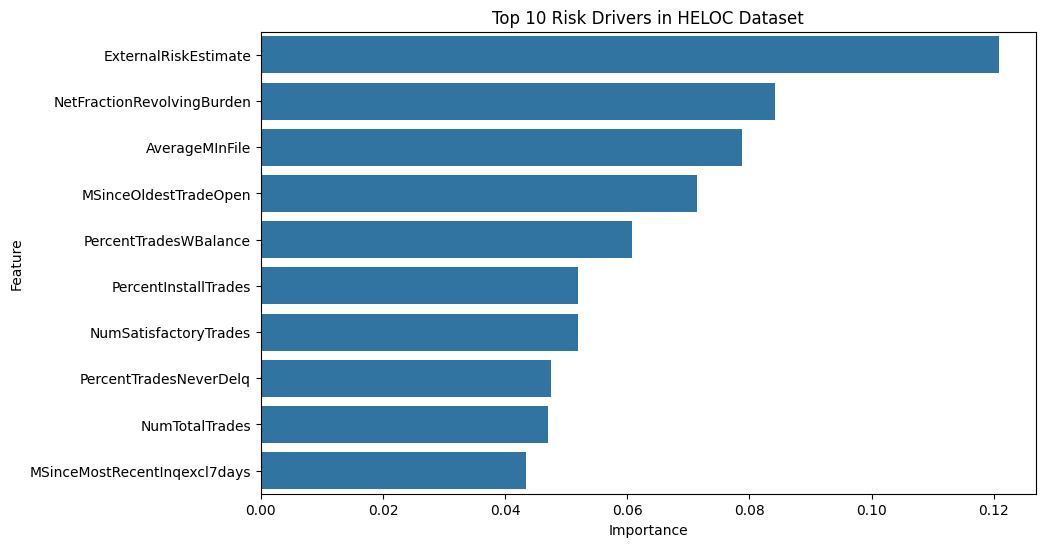

In [28]:
# Plotting the top 10 most important features
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Risk Drivers in HELOC Dataset')
plt.show()

This cell initializes a SHAP (SHapley Additive exPlanations) TreeExplainer with the trained Random Forest model. It then computes the SHAP values for the test dataset (X_test). SHAP values are used to explain the contribution of each feature to the model's output for individual predictions.

In [29]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

This cell generates a SHAP summary plot of type 'dot'. This visualization helps to understand the overall impact of features on the model's predictions. Each dot represents an instance, its color indicates feature value (high/low), and its position on the x-axis shows the SHAP value (impact on model output). The y-axis lists features in order of importance.

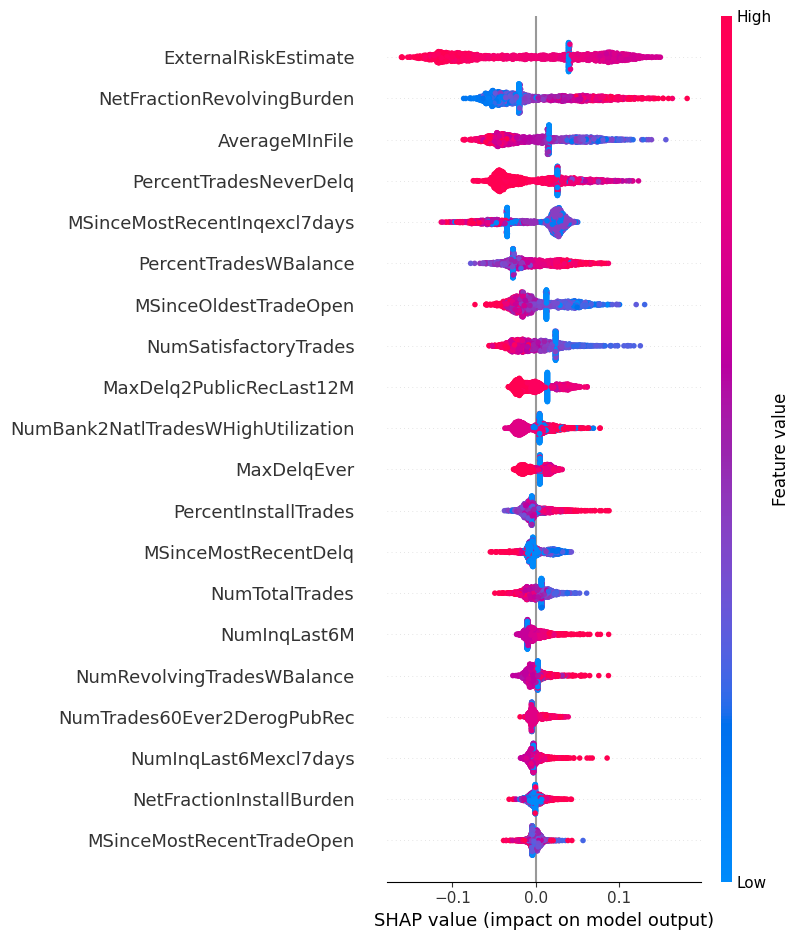

In [30]:
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="dot")

This cell generates a SHAP force plot for a specific sample (index 10) from the test set. The force plot visually explains how individual features contribute to pushing the model's output from the `expected_value` (average prediction) to the final prediction for that sample. Red indicates features pushing the prediction higher, and blue indicates features pushing it lower.

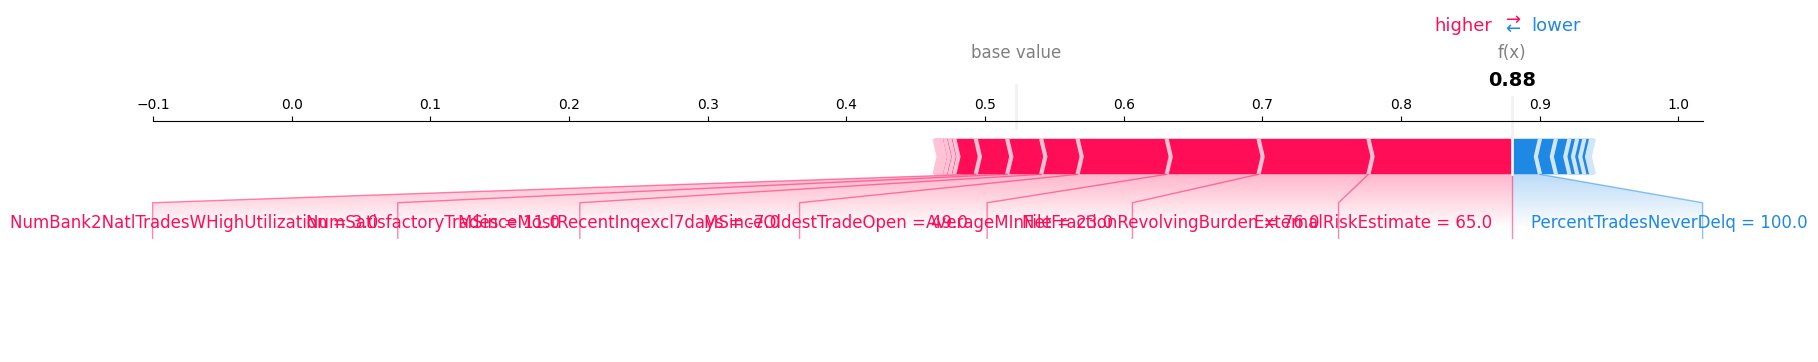

In [31]:
# Initialize javascript for visualization
shap.initjs()

# Choose a specific applicant (e.g., index 10)
sample_idx = 10

# Force Plot: Visualizes the 'push and pull' of features for this specific case
shap.force_plot(
    explainer.expected_value[1],
    shap_values[sample_idx, :, 1],
    X_test.iloc[sample_idx, :],
    matplotlib=True
)

This cell calculates the overall feature importance based on Mean Absolute SHAP values. It extracts the SHAP values for the positive class (class 1), computes the mean of the absolute SHAP values for each feature, and then sorts them to provide a ranked list of features by their impact on the model's predictions.

In [32]:
# Extract SHAP values for the target class (class 1)
shap_values_class_1 = shap_values[:, :, 1]

# Calculate the mean absolute SHAP value for each feature
mean_abs_shap_values = np.mean(np.abs(shap_values_class_1), axis=0)

# Create a DataFrame for better visualization and sorting
shap_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': mean_abs_shap_values
})

# Sort by Mean_Abs_SHAP in descending order
shap_importance_df = shap_importance_df.sort_values(by='Mean_Abs_SHAP', ascending=False)

print("Mean Absolute SHAP Values for Features (Overall Feature Importance):")
display(shap_importance_df)

Mean Absolute SHAP Values for Features (Overall Feature Importance):


,Feature,Mean_Abs_SHAP
0,ExternalRiskEstimate,0.074940
17,NetFractionRevolvingBurden,0.044423
3,AverageMInFile,0.038494
7,PercentTradesNeverDelq,0.036303
14,MSinceMostRecentInqexcl7days,0.033383
22,PercentTradesWBalance,0.025130
1,MSinceOldestTradeOpen,0.024653
4,NumSatisfactoryTrades,0.020887
9,MaxDelq2PublicRecLast12M,0.017831
21,NumBank2NatlTradesWHighUtilization,0.016458


This cell visualizes the overall feature importance derived from the Mean Absolute SHAP values using a bar plot. The plot clearly shows which features have the greatest average impact on the model's output, providing an aggregate view of feature importance.

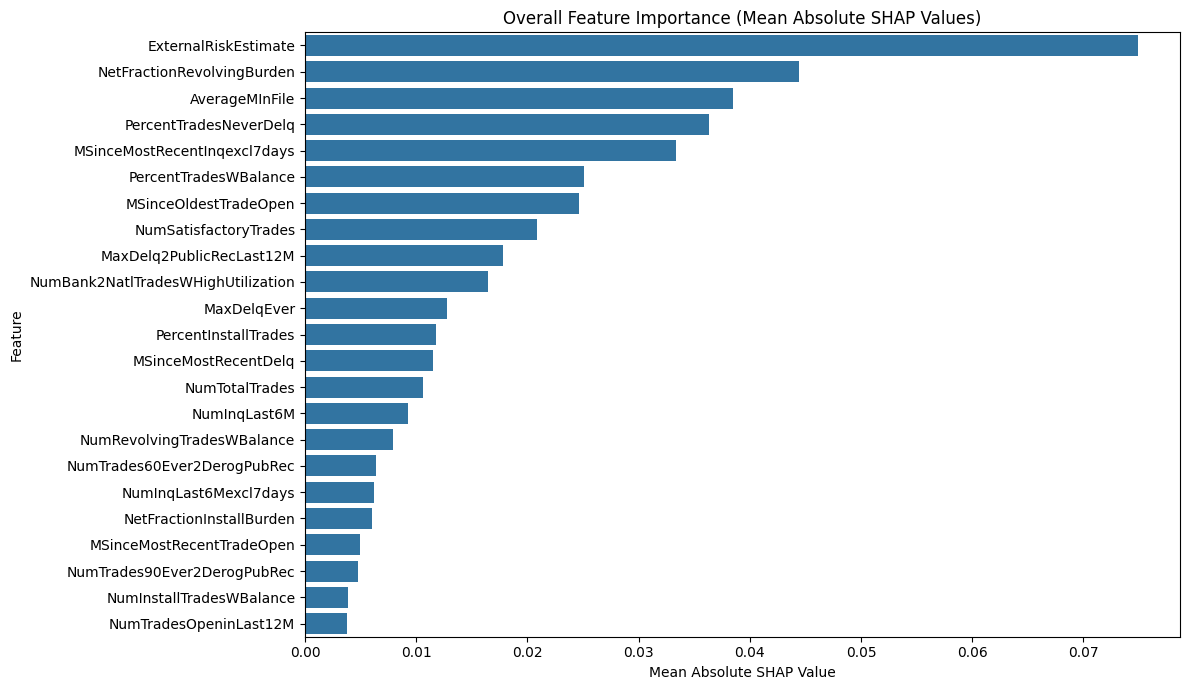

In [33]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Mean_Abs_SHAP', y='Feature', data=shap_importance_df)
plt.title('Overall Feature Importance (Mean Absolute SHAP Values)')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

This cell performs Recursive Feature Elimination (RFE) to select the top 10 most important features. It initializes an RFE estimator with a Random Forest model and fits it to the training data. The selected features are then printed, identifying a reduced set of critical predictors.

In [34]:
# Initialize the model we want to use for selection
# Random Forest is excellent for RFE as it captures non-linear importance
estimator = RandomForestClassifier(n_estimators=50, random_state=42)

# Select the top 10 features
selector = RFE(estimator, n_features_to_select=10, step=1)
selector = selector.fit(X_train, y_train)

# Identify the selected columns
selected_features = X_train.columns[selector.support_]

print("Top 10 Selected Features:")
for i, feat in enumerate(selected_features):
    print(f"{i+1}. {feat}")

Top 10 Selected Features:
1. ExternalRiskEstimate
2. MSinceOldestTradeOpen
3. MSinceMostRecentTradeOpen
4. AverageMInFile
5. NumSatisfactoryTrades
6. PercentTradesNeverDelq
7. NumTotalTrades
8. PercentInstallTrades
9. NetFractionRevolvingBurden
10. PercentTradesWBalance


After selecting the top features using RFE, this cell creates new training and test sets containing only these reduced features. A new Random Forest model (`lean_model`) is trained on this reduced dataset. Finally, it evaluates the `lean_model`'s performance by comparing its AUC-ROC score with that of the original model, demonstrating the impact of feature reduction.

In [35]:
# Create new training and test sets with selected features
X_train_reduced = X_train[selected_features]
X_test_reduced = X_test[selected_features]

# Train the reduced model
lean_model = RandomForestClassifier(n_estimators=100, random_state=42)
lean_model.fit(X_train_reduced, y_train)

# Evaluate
reduced_probs = lean_model.predict_proba(X_test_reduced)[:, 1]
print(f"\nOriginal Model AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Reduced Model (10 Features) AUC: {roc_auc_score(y_test, reduced_probs):.4f}")


Original Model AUC: 0.7664
Reduced Model (10 Features) AUC: 0.7500


This cell visualizes the ranking of all features as determined by the RFE process. A bar plot shows each feature and its rank, where a rank of 1 indicates a selected feature. This helps to understand how RFE prioritized features beyond just the top 10.

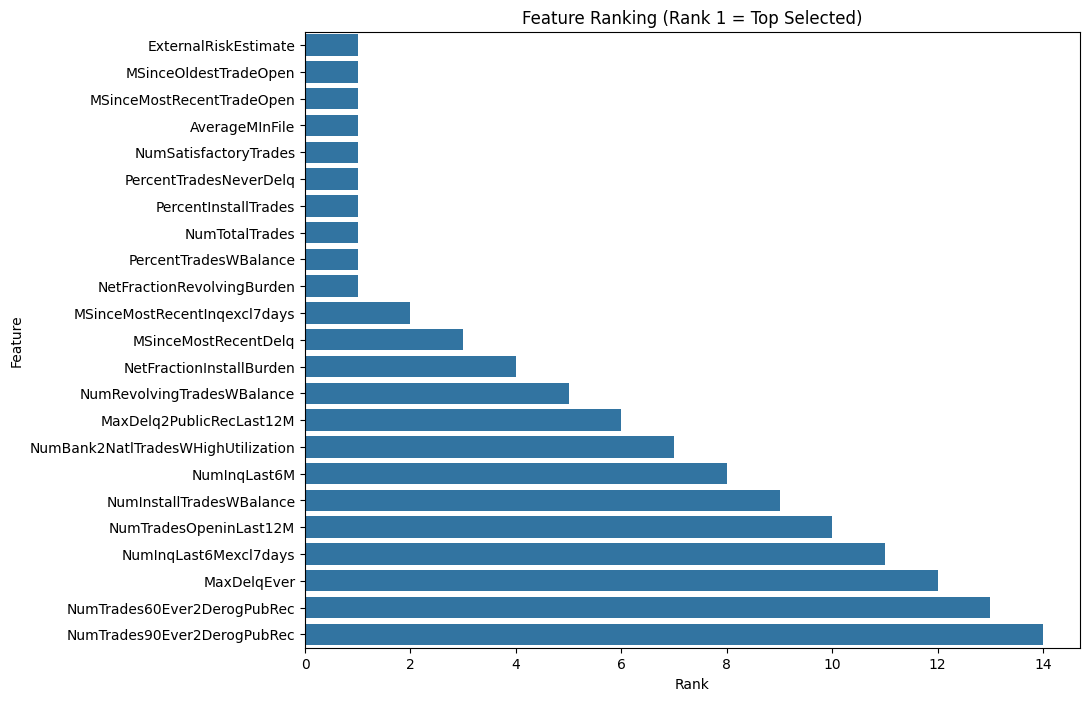

In [36]:
ranking_df = pd.DataFrame({'Feature': X_train.columns, 'Rank': selector.ranking_})
ranking_df = ranking_df.sort_values(by='Rank')

plt.figure(figsize=(10, 8))
sns.barplot(x='Rank', y='Feature', data=ranking_df)
plt.title('Feature Ranking (Rank 1 = Top Selected)')
plt.show()

This cell saves the trained lean model (`lean_model`) and the list of `selected_features` to disk using `joblib`. This allows for the model and its associated feature set to be easily reloaded and used for future predictions or deployments without retraining.

In [37]:
import joblib
joblib.dump(lean_model, 'heloc_scoring_model.pkl')
joblib.dump(selected_features, 'selected_features.pkl')

['selected_features.pkl']

This cell merges the feature importance DataFrames from both Random Forest's built-in `feature_importances_` and SHAP's Mean Absolute SHAP values. It then sorts the combined DataFrame by SHAP importance and displays it, allowing for a direct comparison of how each method ranks the features.

### Comparison of SHAP Importance vs. Random Forest Feature Importance

Let's compare the feature importance rankings derived from Mean Absolute SHAP values and the built-in Random Forest `feature_importances_` attribute.

## Model Interpretability: SHAP vs. Random Forest

In [38]:
# Merge the two importance dataframes
comparison_df = pd.merge(
    feature_importance_df.rename(columns={'Importance': 'RF_Importance'}),
    shap_importance_df.rename(columns={'Mean_Abs_SHAP': 'SHAP_Importance'}),
    on='Feature',
    how='inner'
)

# Sort by one of the importances for easier comparison, e.g., SHAP importance
comparison_df = comparison_df.sort_values(by='SHAP_Importance', ascending=False).reset_index(drop=True)

print("Feature Importance Comparison (SHAP vs. Random Forest):")
display(comparison_df)

Feature Importance Comparison (SHAP vs. Random Forest):


,Feature,RF_Importance,SHAP_Importance
0,ExternalRiskEstimate,0.120838,0.074940
1,NetFractionRevolvingBurden,0.084161,0.044423
2,AverageMInFile,0.078781,0.038494
3,PercentTradesNeverDelq,0.047542,0.036303
4,MSinceMostRecentInqexcl7days,0.043367,0.033383
5,PercentTradesWBalance,0.060724,0.025130
6,MSinceOldestTradeOpen,0.071377,0.024653
7,NumSatisfactoryTrades,0.051924,0.020887
8,MaxDelq2PublicRecLast12M,0.024010,0.017831
9,NumBank2NatlTradesWHighUtilization,0.031283,0.016458


This cell visualizes the comparison of feature importances between SHAP and Random Forest using a grouped bar plot. By melting the DataFrame and plotting both 'RF_Importance' and 'SHAP_Importance' for each feature, it provides a clear side-by-side view of how the two methods rank and value different features.

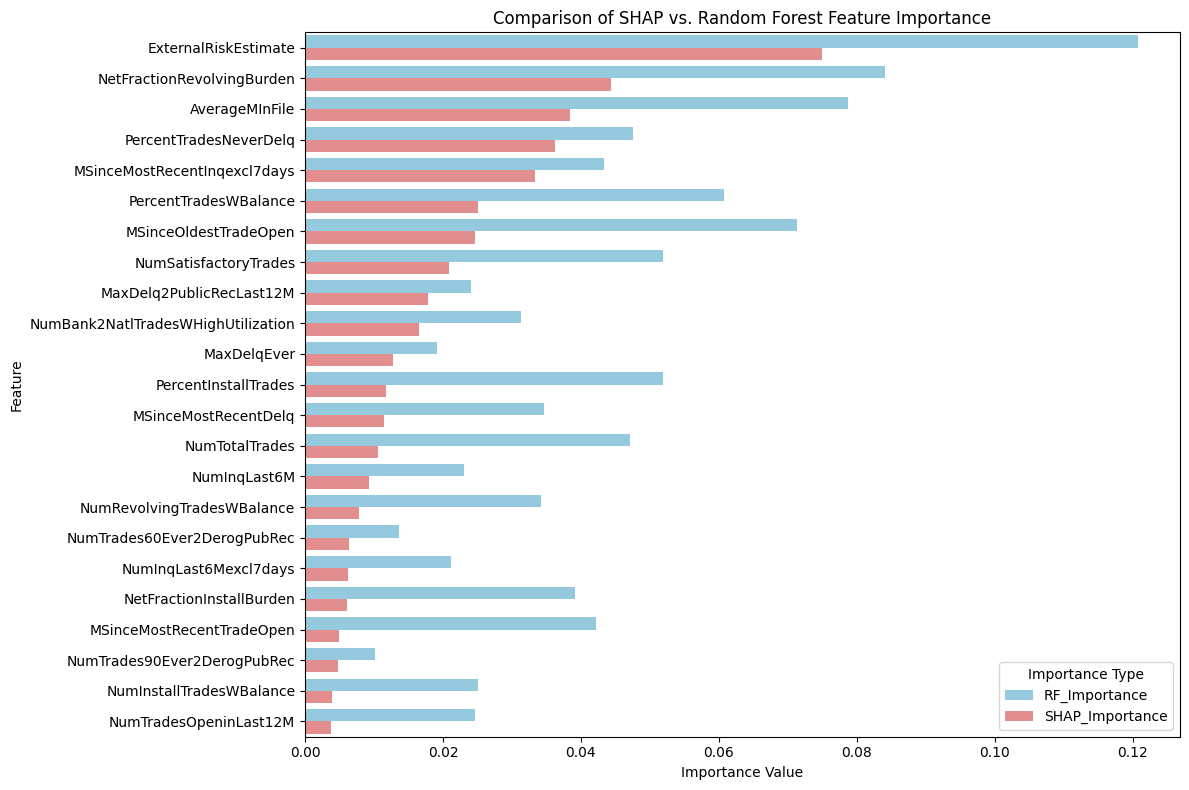

In [39]:
# Plotting the comparison of feature importances
plt.figure(figsize=(12, 8))

# Melt the DataFrame to easily plot both importance metrics on the same bar chart
melted_comparison_df = comparison_df.melt(id_vars='Feature', var_name='Importance_Type', value_name='Importance_Value')

sns.barplot(x='Importance_Value', y='Feature', hue='Importance_Type', data=melted_comparison_df, palette={'RF_Importance': 'skyblue', 'SHAP_Importance': 'lightcoral'})
plt.title('Comparison of SHAP vs. Random Forest Feature Importance')
plt.xlabel('Importance Value')
plt.ylabel('Feature')
plt.legend(title='Importance Type')
plt.tight_layout()
plt.show()

This cell calculates and prints the Pearson correlation coefficient between the 'RF_Importance' and 'SHAP_Importance' columns. This statistical measure quantifies the linear relationship between the two different feature importance ranking methods, indicating how consistent their assessments are.

In [40]:
correlation = comparison_df['RF_Importance'].corr(comparison_df['SHAP_Importance'])
print(f"Pearson correlation between RF Importance and SHAP Importance: {correlation:.4f}")

Pearson correlation between RF Importance and SHAP Importance: 0.8734


This cell generates a box plot to visualize the distribution of `ExternalRiskEstimate` for both good (target=0) and bad (target=1) loans. This plot helps to visually assess if there's a noticeable difference in risk estimates between the two target classes.

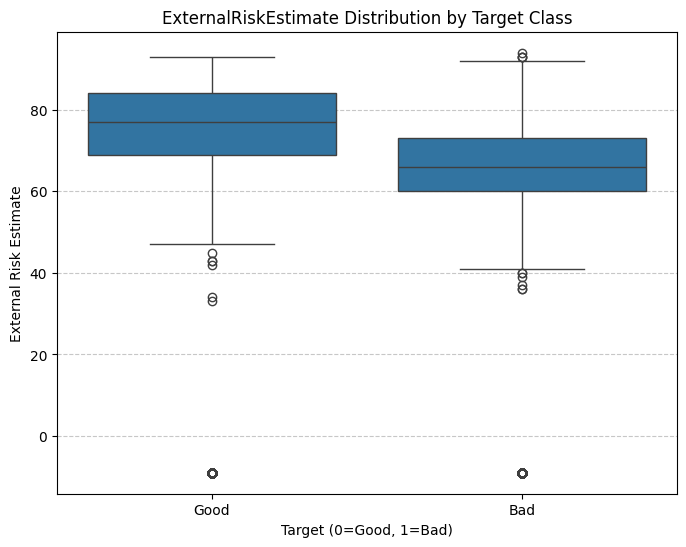

In [41]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='target', y='ExternalRiskEstimate', data=df)
plt.title('ExternalRiskEstimate Distribution by Target Class')
plt.xlabel('Target (0=Good, 1=Bad)')
plt.ylabel('External Risk Estimate')
plt.xticks([0, 1], ['Good', 'Bad'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This cell calculates the Pearson correlation coefficient between the top 5 most important features (excluding 'ExternalRiskEstimate' to focus on other key drivers) and the target variable. It then displays these correlations, indicating the linear relationship and direction of influence each feature has on loan risk.

### Correlation of Top Features with Target

Let's calculate the Pearson correlation coefficient between the top 5 most important features (based on Mean Absolute SHAP values, excluding 'ExternalRiskEstimate') and the target variable. This will help us understand the linear relationship between these features and loan risk.

In [42]:
# Get the top features from shap_importance_df, excluding 'ExternalRiskEstimate'
top_shap_features = shap_importance_df[shap_importance_df['Feature'] != 'ExternalRiskEstimate'].head(5)['Feature'].tolist()

# Include the target variable for correlation calculation
features_for_correlation = top_shap_features + ['target']

# Create a subset DataFrame
correlation_df = df[features_for_correlation]

# Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

# Extract correlations with the target variable
target_correlations = correlation_matrix['target'].drop('target').sort_values(ascending=False)

print("Pearson Correlation with Target Variable:")
display(target_correlations)

Pearson Correlation with Target Variable:


,target
NetFractionRevolvingBurden,0.298174
PercentTradesWBalance,0.198554
MSinceMostRecentInqexcl7days,-0.110253
PercentTradesNeverDelq,-0.122010
AverageMInFile,-0.209168


This cell visualizes the Pearson correlation coefficients of the top features with the target variable using a bar plot. This provides a clear graphical representation of which features have the strongest positive or negative linear relationships with the loan risk.

/tmp/ipykernel_4793/3305142049.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_correlations.values, y=target_correlations.index, palette='viridis')


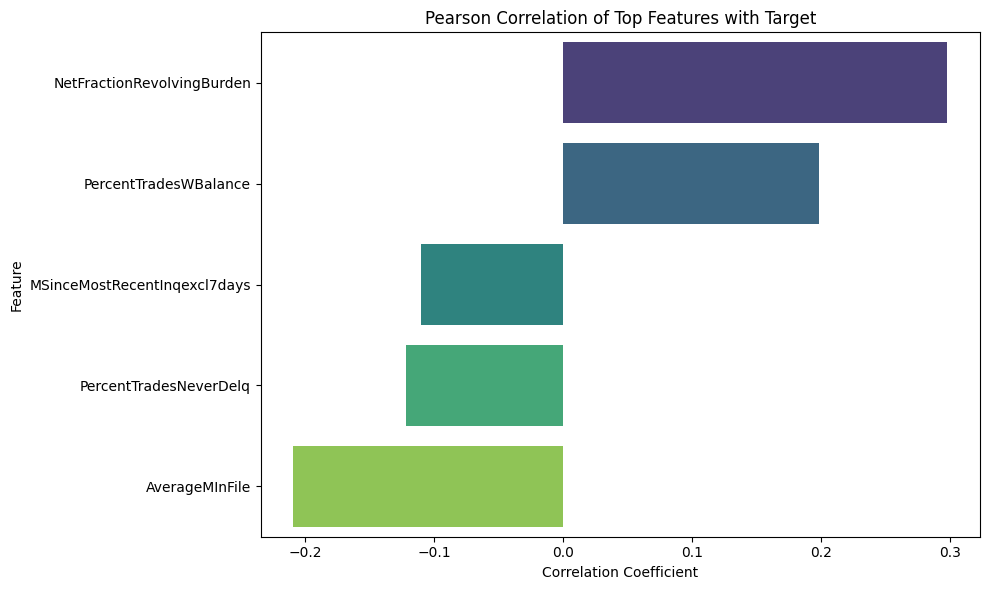

In [43]:
plt.figure(figsize=(10, 6))
sns.barplot(x=target_correlations.values, y=target_correlations.index, palette='viridis')
plt.title('Pearson Correlation of Top Features with Target')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

This cell performs an independent samples t-test (specifically Welch's t-test, assuming unequal variances) to compare the mean `ExternalRiskEstimate` between good loans (target=0) and bad loans (target=1). It prints the means, the t-statistic, and the p-value, then interprets the result to determine if the observed difference is statistically significant.

### T-test for ExternalRiskEstimate by Target Class

Let's perform an independent samples t-test to statistically compare the mean `ExternalRiskEstimate` for the two target classes (Good vs. Bad loans). This will help determine if the observed differences are statistically significant.

In [44]:
from scipy import stats

# Separate ExternalRiskEstimate by target class
external_risk_good = df[df['target'] == 0]['ExternalRiskEstimate']
external_risk_bad = df[df['target'] == 1]['ExternalRiskEstimate']

# Perform independent samples t-test
t_stat, p_value = stats.ttest_ind(external_risk_good, external_risk_bad, equal_var=False) # Welch's t-test assuming unequal variances

print(f"Mean ExternalRiskEstimate for Good Loans (target=0): {external_risk_good.mean():.2f}")
print(f"Mean ExternalRiskEstimate for Bad Loans (target=1): {external_risk_bad.mean():.2f}")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("\nSince the p-value is less than the significance level (0.05), we reject the null hypothesis.")
    print("There is a statistically significant difference between the mean ExternalRiskEstimate of good and bad loans.")
else:
    print("\nSince the p-value is greater than the significance level (0.05), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference between the mean ExternalRiskEstimate of good and bad loans.")

Mean ExternalRiskEstimate for Good Loans (target=0): 72.21
Mean ExternalRiskEstimate for Bad Loans (target=1): 63.04

T-statistic: 22.6571
P-value: 0.0000

Since the p-value is less than the significance level (0.05), we reject the null hypothesis.
There is a statistically significant difference between the mean ExternalRiskEstimate of good and bad loans.
